#### **Self in Self-attention**
The **Self** refers to the mechanism's ability to compute attention weights by relating different positions within a single input sequence. It assesses and learns the relationships and dependencies between various parts of the input itself, such as words in a sentence or pixels in an image. 

#### **A Simple Self-attention mechanism without trainable weights**
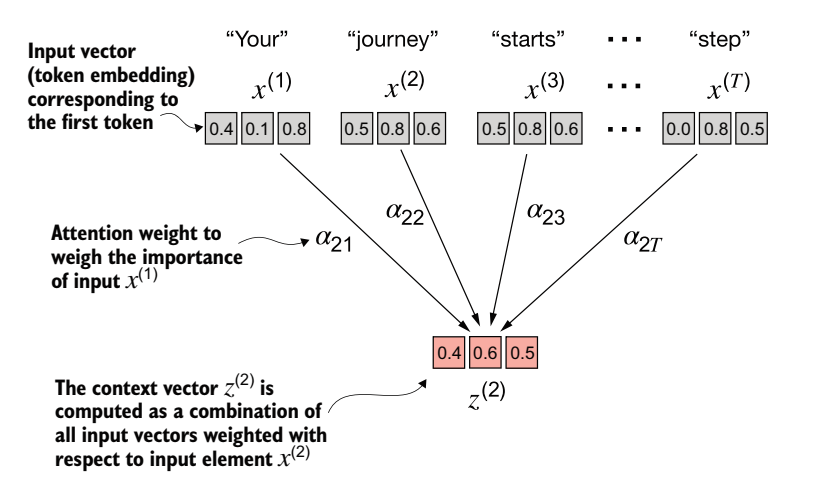

In **Self attention**, Our goal is to calculate context vectors **z_(i)** for each element **x_(i)** in the input sequence. A Context vector can be intrepreted as enriched embedding vector. 

In [6]:
import torch 
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],   ### Your
     [0.55, 0.87, 0.66],   ### journey
     [0.57, 0.85, 0.64],   ### starts
     [0.22, 0.58, 0.33],   ### with
     [0.77, 0.25, 0.10],   ### one
     [0.05, 0.80, 0.55]    ### step
    ]
)

query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
    
    
print(attn_scores_2)


### then normalize the scores 
attn_scores_2_tmp = attn_scores_2 / attn_scores_2.sum()
print(attn_scores_2_tmp)



### COMPUTTING NORMALIZATION USING SOFTMAX FUNCTION 
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print(attn_weights_2_naive)


### USING TORCH BUILT IN FUNCTION
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print(attn_weights_2)



#### Context vector is the weighted sum of all input vectors, obtained by multiplying each input vector by its corresponding attention weights. 

query = inputs[1]
context_vector_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector_2 += attn_weights_2[i] * x_i
print(context_vector_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.4419, 0.6515, 0.5683])


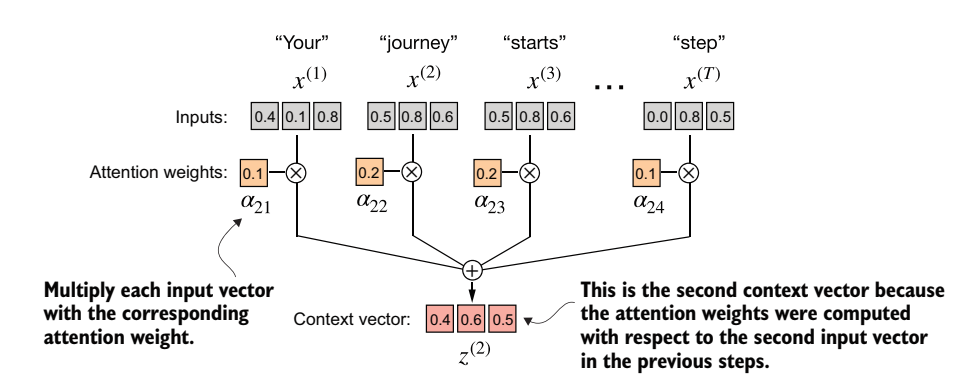

In [7]:
## computing attention weights for all input tokens
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i][j] = torch.dot(x_i, x_j) 
        
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [8]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


#### **Implementing Self attention with trainable weights**

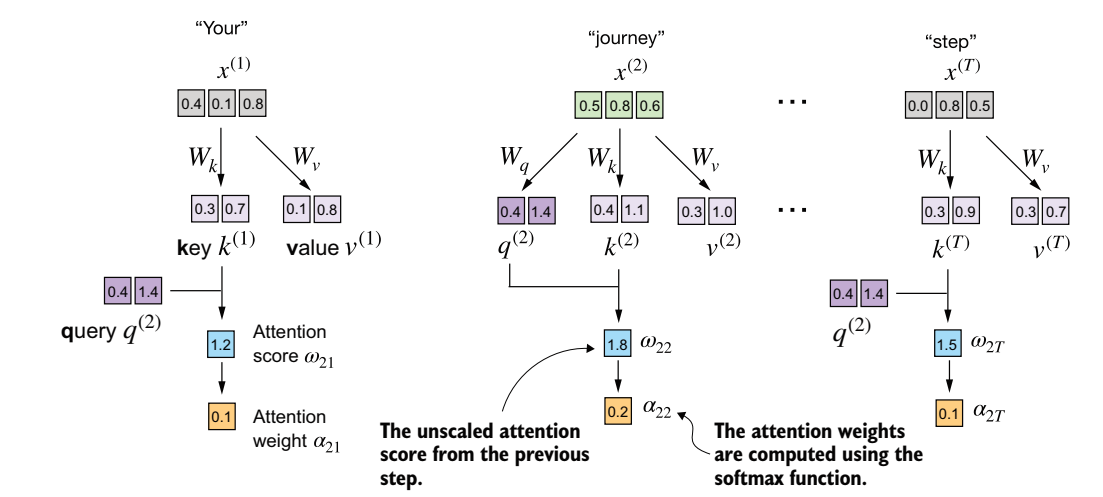

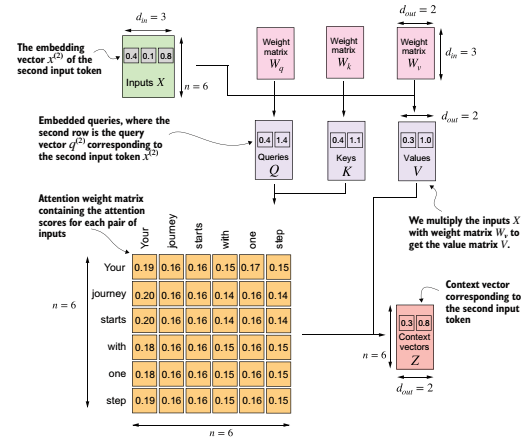

The goal of self-attention is to update the representation of a token by incorporating information from all other tokens in the sequence, weighted by their relevance
1. **The Projections (Linear Layers)**: For every input embedding $x$, we create three distinct vectors using weight matrices ($W_q, W_k, W_v$):
 - Query ($q$): "What am I looking for?"
 - Key ($k$): "What information do I contain?"
 - Value ($v$): "What information am I willing to share?"

2. **Calculating Attention Scores**: We calculate how much focus token $i$ should place on token $j$ by taking the dot product of the Query of $i$ and the Key of $j$.$$\text{score}_{i,j} = q_i \cdot k_j$$.

3. **Scaling and Softmax**: To prevent the scores from exploding (which leads to small gradients), we scale the scores by the square root of the dimension of the keys ($\sqrt{d_k}$). We then apply a Softmax to turn these scores into probabilities that sum to 1.4. The Weighted SumFinally, we multiply each Value ($v$) by its corresponding attention weight and sum them up to produce the Context Vector ($z$).